In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.climate.stochastic_generation import (
    SpatialFieldModel,
    fit_spatial_model,
    generate_random_field,
    generate_random_field_fast,
    check_random_field,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Spatial Random Field Generation (CoSMoS_py)

A **spatial random field** assigns a random variable to every location in space so that nearby points are more similar than distant ones. In hydrology this is used to generate realistic gridded precipitation or temperature ensembles that simultaneously reproduce:

1. **Marginal distribution** — the statistical behaviour of each pixel/station (mean, variance, heavy tail, dry-day fraction).
2. **Spatial correlation** — similarity between nearby stations decays with distance.
3. **Temporal persistence** — today's rainfall tends to occur in similar locations as yesterday's.

---

### Methodology — VAR(p) + ACTF

CoSMoS_py implements the **Biller & Nelson (2003)** method extended by **Papalexiou & Serinaldi (2020)**:

1. A **Vector Autoregressive model of order p (VAR(p))** is fitted in the Gaussian copula space.  
   The VAR imposes the spatio-temporal correlation structure through a covariance matrix built from the chosen STCS.
2. The Gaussian residuals are mapped to the target marginal via the **ACTF** (AutoCorrelation Transformation Function) — a copula-based quantile transform.

The result is a time series of spatial fields that simultaneously reproduce the target marginal, the inter-site spatial correlation, and the temporal autocorrelation.

---

### Workflow

```
SpatialFieldModel(dist, dist_params, p0, stcs_id, ...)
    → .fit(spacepoints)      # builds the VAR covariance matrix
    → .simulate(n_steps)     # generates the fields
    → .diagnostics()         # checks convergence against targets
```

---

### Main parameters

| Parameter | Options | Description |
|-----------|---------|-------------|
| `dist` | `gengamma`, `burrXII`, `paretoII`, `burrIII`, `gev` | Marginal distribution for each pixel |
| `p0` | [0, 1) | Probability of exact zero (dry-day fraction) |
| `p` | 1, 2, … | VAR order — number of temporal lags (p=1 is usually sufficient) |
| `stcs_id` | `clayton`, `gneiting14`, `gneiting16` | Spatio-temporal correlation structure |
| `dep_structure` | `gauss`, `student`, `bardossy` | Copula for the VAR spatial residuals |
| `scale_factor` | float | Distance between pixels in regular grids (default 1) |
| `advection_id` | `uniform`, `rotation`, `spiral` | Storm advection pattern |

---

### Installation

```bash
pip install -e /path/to/CoSMoS_py
# Source: https://github.com/navass11/CoSMoS_py
```

**Reference:** Papalexiou & Serinaldi (2020), *Water Resources Research*, 56(2), e2019WR026331.

---
## 1. Regular grid — daily precipitation

Simulate 1 year of daily precipitation on a **6×6 regular grid** (36 pixels). Pixels are spaced 1 distance unit apart (controlled by `scale_factor`).

### Marginal distribution: `gengamma` (generalised gamma)

The generalised gamma is a flexible heavy-tailed distribution suitable for daily precipitation:

$$f(x) \propto x^{\text{shape1}\cdot\text{shape2}-1} \exp\!\left[-\left(\frac{x}{\text{scale}}\right)^{\text{shape2}}\right]$$

- **`scale`** — controls the typical magnitude of wet-day amounts (approximately the characteristic rainfall intensity in mm)
- **`shape1`** — controls skewness: small values (< 1) → highly skewed; large values → near-symmetric
- **`shape2`** — controls the tail: shape2 < 1 → heavier tail than the standard gamma

### Intermittency: `p0`

`p0=0.65` means 65% of pixel-days are exactly zero (dry). The remaining 35% follow the `gengamma` distribution for wet-day amounts. This value is typical for daily precipitation in Mediterranean or semi-arid climates.

### Clayton STCS parameters

- **`copulaarg` (θ=2.0)** — Clayton copula strength. Higher θ → higher joint probability of simultaneous wet days at neighbouring pixels.
- **`scfarg` (spatial ACF)** — `scale=2.0` → adjacent pixels (dist=1) share correlation r ≈ 0.56.
- **`tcfarg` (temporal ACF)** — `scale=3.0` → lag-1 day correlation r ≈ 0.66 (moderate day-to-day persistence).

In [3]:
# Marginal: generalised gamma — scale=5 mm, moderate variability
# p0=0.65 → 65% dry days
# STCS Clayton with Weibull ACFs:
#   spatial scale=2.0 → r≈0.56 between adjacent pixels (realistic)
#   temporal scale=3.0 → r≈0.66 at lag-1 day (clear day-to-day persistence)

model_precip = SpatialFieldModel(
    dist="gengamma",
    dist_params={"scale": 5.0, "shape1": 0.8, "shape2": 0.5},
    p0=0.65,
    p=1,
    stcs_id="clayton",
    stcs_params={
        "scfid":     "weibull",
        "tcfid":     "weibull",
        "copulaarg": 2.0,
        "scfarg":    {"scale": 2.0, "shape": 0.8},   # spatial:  r≈0.56 at dist=1
        "tcfarg":    {"scale": 3.0, "shape": 0.8},   # temporal: r≈0.66 at lag=1
    },
)

print("Building VAR model for 6×6 grid ...")
import time; t0 = time.time()
model_precip.fit(spacepoints=6)
print(f"  Done in {time.time()-t0:.1f}s — model ready")

Building VAR model for 6×6 grid ...
  Done in 3.9s — model ready


In [4]:
# Simulate 365 days
import numpy as np
field = model_precip.simulate(n_steps=365)   # FieldResult, shape (365, 36)
field_arr = np.asarray(field)
print(f"Simulated field: {field_arr.shape}  (n_steps × n_sites)")
print(f"Mean daily precipitation : {field_arr.mean():.2f} mm")
print(f"Wet-day fraction         : {(field_arr > 0).mean():.3f}  (target: 0.35)")
print(f"Max daily precipitation  : {field_arr.max():.1f} mm")


Simulated field: (365, 36)  (n_steps × n_sites)
Mean daily precipitation : 9.07 mm
Wet-day fraction         : 0.336  (target: 0.35)
Max daily precipitation  : 1043.9 mm


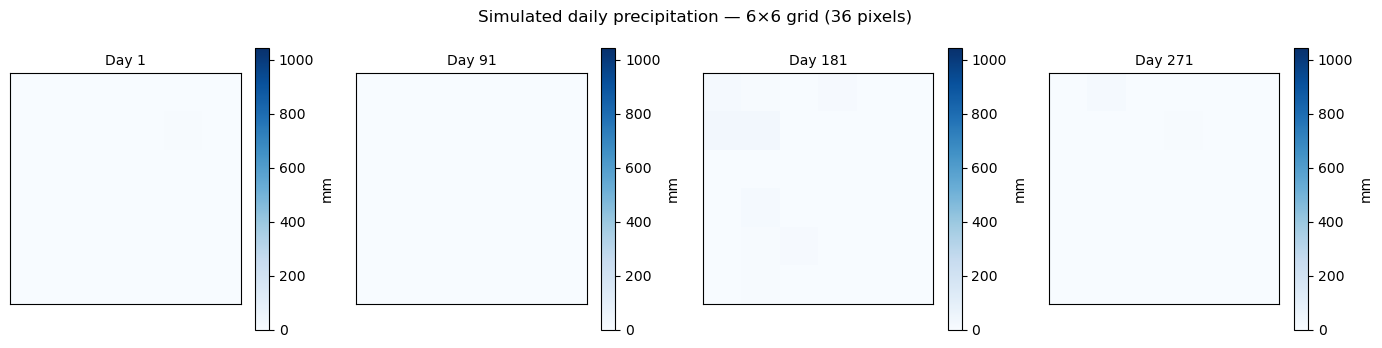

In [5]:
m = 6    # grid side
days = [0, 90, 180, 270]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, day_idx in zip(axes, days):
    Z = np.asarray(field)[day_idx].reshape(m, m)
    im = ax.imshow(Z, cmap="Blues", vmin=0, vmax=np.asarray(field).max())
    ax.set_title(f"Day {day_idx + 1}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, label="mm")
plt.suptitle("Simulated daily precipitation — 6×6 grid (36 pixels)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Irregular station locations

Instead of a regular grid, pass an **(n_sites × 2) coordinate array** to simulate at arbitrary gauge locations — useful for validating synthetic series against rain gauge or streamflow records.

### Key differences from grid simulation

- The VAR model is built using the **actual inter-station distances**; no uniform pixel spacing is assumed.
- Coordinates can be in km, degrees, or any consistent Euclidean unit — only pairwise distances matter.
- `scfarg scale` must be calibrated to the coordinate units: here stations span ~10 km, so `scale=5` maintains r ≈ 0.56 at ≈ 4 km separation.

### Setup

8 gauge stations distributed across a ~10×8 km domain. Correlation between stations depends solely on their mutual distance — far-apart stations (S0 and S7, dist ≈ 12.8 km) will have lower correlation than adjacent stations (S0 and S3, dist ≈ 4.7 km).

In [6]:
# 8 gauge stations (lon/lat or any Euclidean coordinates in km)
coords = np.array([
    [0.0, 0.0],
    [5.0, 0.0],
    [10.0, 0.0],
    [2.5, 4.0],
    [7.5, 4.0],
    [0.0, 8.0],
    [5.0, 8.0],
    [10.0, 8.0],
])

model_stations = SpatialFieldModel(
    dist="gengamma",
    dist_params={"scale": 5.0, "shape1": 0.8, "shape2": 0.5},
    p0=0.65,
    stcs_id="clayton",
    stcs_params={
        "scfid": "weibull",
        "tcfid": "weibull",
        "copulaarg": 2.0,
        "scfarg": {"scale": 5.0, "shape": 0.8},   # spatial: r≈0.56 at 4 km
        "tcfarg": {"scale": 3.0, "shape": 0.8},   # temporal: r≈0.66 at lag=1
    },
)

import time; t0 = time.time()
model_stations.fit(spacepoints=coords)
print(f"Irregular site model fitted in {time.time()-t0:.1f}s")
field_stations = model_stations.simulate(n_steps=3650)   # 10 years
field_sta_arr = np.asarray(field_stations)
print(f"Simulated at {coords.shape[0]} sites over 10 years: {field_sta_arr.shape}")
print(f"Mean by site: {field_sta_arr.mean(axis=0).round(2)}")

Irregular site model fitted in 3.9s
Simulated at 8 sites over 10 years: (3650, 8)
Mean by site: [6.45 6.91 7.64 6.8  6.75 6.66 6.61 7.49]


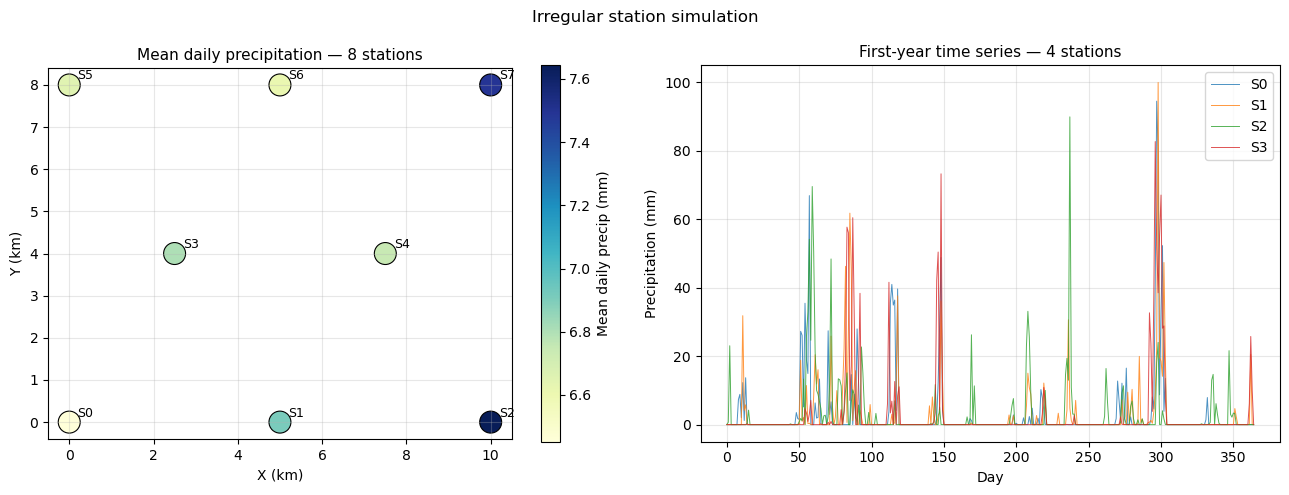

In [7]:
mean_by_site = np.asarray(field_stations).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter map
sc = axes[0].scatter(coords[:, 0], coords[:, 1], c=mean_by_site,
                     cmap="YlGnBu", s=250, edgecolors="k", linewidths=0.8)
plt.colorbar(sc, ax=axes[0], label="Mean daily precip (mm)")
for i, (x, y) in enumerate(coords):
    axes[0].annotate(f"S{i}", (x, y), textcoords="offset points",
                     xytext=(6, 4), fontsize=9)
axes[0].set_xlabel("X (km)"); axes[0].set_ylabel("Y (km)")
axes[0].set_title("Mean daily precipitation — 8 stations", fontsize=11)
axes[0].set_aspect("equal"); axes[0].grid(alpha=0.3)

# Time series for 4 stations
df_sta = pd.DataFrame(field_sta_arr[:365, :4],
                      columns=[f"S{i}" for i in range(4)])
df_sta.plot(ax=axes[1], lw=0.7, alpha=0.8)
axes[1].set_xlabel("Day"); axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_title("First-year time series — 4 stations", fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle("Irregular station simulation", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Spatio-temporal correlation structures (STCS)

The STCS is the mathematical model that defines how correlation decays jointly in space and time. It is used internally to build the VAR covariance matrix.

---

### Clayton STCS (recommended for precipitation)

Combines independent spatial and temporal ACFs through a **Clayton copula**:

$$\rho(h, \tau) = \phi_C\!\left(r_s(h),\, r_t(\tau);\, \theta\right)$$

where $r_s(h)$ and $r_t(\tau)$ are the spatial and temporal ACF values (computed via Weibull functions), and $\phi_C$ is the Clayton copula with parameter θ (`copulaarg`).

**Weibull ACF:**

$$r(h) = \exp\!\left[-\left(\frac{h}{\text{scale}}\right)^{\text{shape}}\right]$$

| Parameter | Effect |
|-----------|--------|
| `scale` | Correlation range: distance/lag at which r = e⁻¹ ≈ 0.37 |
| `shape` | Decay shape: shape < 1 → slow near-origin decay (nugget-free); shape = 1 → pure exponential; shape > 1 → rapid near-origin decay |
| `copulaarg` (θ) | Joint spatio-temporal dependence strength: θ → 0 = independence; large θ = strong dependence |

---

### Gneiting (2002) STCS (for continuous variables)

A **non-separable** space-time covariance — the spatial range varies with time lag, capturing the spatial decorrelation of meteorological systems over time:

$$\rho(h, \tau) = \frac{1}{\psi(\tau)^\tau} \exp\!\left[\frac{-c\,|h|^{2\gamma}}{\psi(\tau)^{\gamma/\beta}}\right], \quad \psi(\tau) = \left(a|\tau|^{2\alpha}+1\right)^\beta$$

Available as `gneiting14` (Eq. 14) and `gneiting16` (Eq. 16, Matérn variant). Used in section 8 for continuous fields.

| ID | Model | Key parameters |
|----|-------|----------------|
| `clayton` | Clayton copula of Weibull ACFs | `copulaarg` (θ), `scfarg` (scale, shape), `tcfarg` (scale, shape) |
| `gneiting14` | Gneiting (2002) Eq. 14 | `a`, `c`, `alpha`, `beta`, `gamma`, `tau` |
| `gneiting16` | Gneiting (2002) Eq. 16 (Matérn) | `a`, `c`, `alpha`, `beta`, `nu`, `tau` |

Spatial correlation (scfarg) at selected distances:
  dist=1:  scale=0.5: 0.175  |  scale=2.0: 0.563  |  scale=5.0: 0.759
  dist=2:  scale=0.5: 0.048  |  scale=2.0: 0.368  |  scale=5.0: 0.619
  dist=3:  scale=0.5: 0.015  |  scale=2.0: 0.251  |  scale=5.0: 0.515
  dist=5:  scale=0.5: 0.002  |  scale=2.0: 0.125  |  scale=5.0: 0.368

Temporal correlation (tcfarg) at selected lags:
  lag=1:   scale=1.0: 0.368  |  scale=3.0: 0.660  |  scale=6.0: 0.788
  lag=3:   scale=1.0: 0.090  |  scale=3.0: 0.368  |  scale=6.0: 0.563
  lag=5:   scale=1.0: 0.027  |  scale=3.0: 0.222  |  scale=6.0: 0.421
  lag=7:   scale=1.0: 0.009  |  scale=3.0: 0.140  |  scale=6.0: 0.323


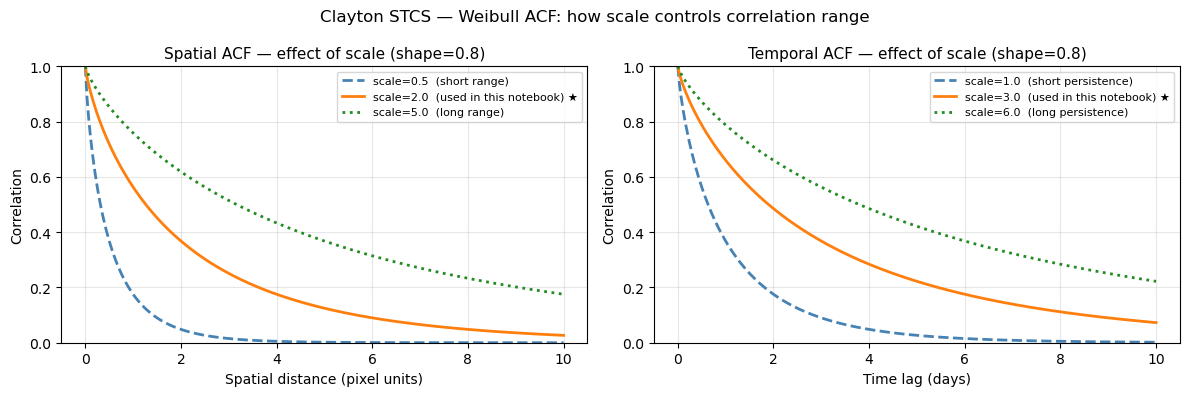

In [8]:

# How the Weibull ACF parameters control spatial and temporal correlation decay
# (Clayton STCS — used throughout this notebook)
def weibull_acf(h, scale, shape):
    return np.exp(-(np.abs(h) / scale) ** shape)

s_range = np.linspace(0, 10, 300)
t_range = np.linspace(0, 10, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: spatial decay for three scale values (shape=0.8 fixed) ─────────────
spatial_configs = [
    (0.5, 0.8, "steelblue",  "--", "scale=0.5  (short range)"),
    (2.0, 0.8, "C1",         "-",  "scale=2.0  (used in this notebook) ★"),
    (5.0, 0.8, "forestgreen",":",  "scale=5.0  (long range)"),
]
for scale, shape, color, ls, label in spatial_configs:
    axes[0].plot(s_range, weibull_acf(s_range, scale, shape),
                 color=color, ls=ls, lw=2, label=label)
axes[0].set_xlabel("Spatial distance (pixel units)")
axes[0].set_ylabel("Correlation")
axes[0].set_title("Spatial ACF — effect of scale (shape=0.8)", fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_ylim([0, 1])

# ── Right: temporal decay for three scale values ──────────────────────────────
temporal_configs = [
    (1.0, 0.8, "steelblue",  "--", "scale=1.0  (short persistence)"),
    (3.0, 0.8, "C1",         "-",  "scale=3.0  (used in this notebook) ★"),
    (6.0, 0.8, "forestgreen",":",  "scale=6.0  (long persistence)"),
]
for scale, shape, color, ls, label in temporal_configs:
    axes[1].plot(t_range, weibull_acf(t_range, scale, shape),
                 color=color, ls=ls, lw=2, label=label)
axes[1].set_xlabel("Time lag (days)")
axes[1].set_ylabel("Correlation")
axes[1].set_title("Temporal ACF — effect of scale (shape=0.8)", fontsize=11)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_ylim([0, 1])

plt.suptitle("Clayton STCS — Weibull ACF: how scale controls correlation range", fontsize=12)
plt.tight_layout()
plt.show()

print("Spatial correlation (scfarg) at selected distances:")
for d in [1, 2, 3, 5]:
    vals = "  |  ".join(f"scale={s}: {weibull_acf(d,s,0.8):.3f}" for s in [0.5, 2.0, 5.0])
    print(f"  dist={d}:  {vals}")
print("\nTemporal correlation (tcfarg) at selected lags:")
for lag in [1, 3, 5, 7]:
    vals = "  |  ".join(f"scale={s}: {weibull_acf(lag,s,0.8):.3f}" for s in [1.0, 3.0, 6.0])
    print(f"  lag={lag}:   {vals}")


### Calibration guide for `scfarg` and `tcfarg`

The figure shows the **Weibull ACF** for three `scale` values (shape=0.8 fixed). Use it to choose STCS parameters:

| Desired behaviour | `scfarg scale` | `tcfarg scale` |
|-------------------|---------------|---------------|
| Nearly independent pixels (noisy field) | 0.3–0.8 | 0.5–1.0 |
| Moderate spatial coherence ★ | 1.5–3.0 | 2.0–4.0 |
| Very smooth fields (high correlation) | 5.0–10.0 | 5.0–10.0 |

★ Values used in this notebook: scale=2.0 (spatial), scale=3.0 (temporal).

**Rule of thumb:** set `scale` ≈ the distance (or lag) at which you want r ≈ 0.37 (the e⁻¹ value).

The `shape` parameter controls the curvature of the decay:
- `shape < 1` → slow decay near the origin with a long tail (recommended for precipitation)
- `shape = 1` → pure exponential decay
- `shape > 1` → rapid near-origin decay (appropriate for smooth continuous variables)

---
## 4. Spatial copula (dependence structure)

The `dep_structure` parameter selects the **copula** used for the spatial residuals within the VAR model. The copula does NOT change the marginal distribution of each pixel — it only controls the **joint dependence structure** between sites.

### Why it matters in hydrology

Concurrent extreme precipitation at multiple locations is the primary driver of large floods. A Gaussian copula **underestimates** the probability of several sites simultaneously exceeding their high quantiles — this is known as **tail dependence**.

The Student-t copula corrects this: if one site is in the extreme tail, others are *more likely* to also be extreme.

### Available types

| `dep_structure` | Tails | When to use |
|-----------------|-------|-------------|
| `gauss` | Light (symmetric) | Default — most applications |
| `student` | Heavy (symmetric) | When joint extremes are critical (floods, simultaneous droughts) |
| `bardossy` | Asymmetric | Spatially asymmetric extremes (fronts, eddies) |

**Parameter `dep_arg`:**
- For `student`: degrees of freedom ν. Lower ν → heavier tails. Typical range: 3–10.
- For `bardossy`: asymmetry parameter m.

### Intuition

- **ν → ∞**: Student-t converges to the Gaussian copula.
- **ν = 5**: moderate tail dependence — good default when joint extremes matter.
- **ν = 2–3**: very heavy tails — only if data clearly shows evidence of simultaneous extremes.

Fitting Gaussian copula model ...
  done in 3.9s
Fitting Student-t copula model (df=5) ...
  done in 3.9s

Mean inter-station correlation — Gaussian: 0.317   Student-t: 0.389
Joint exceedance at 90th pct (S0 vs S3):  Gaussian=0.0432  Student-t=0.0432  Independence=0.0100


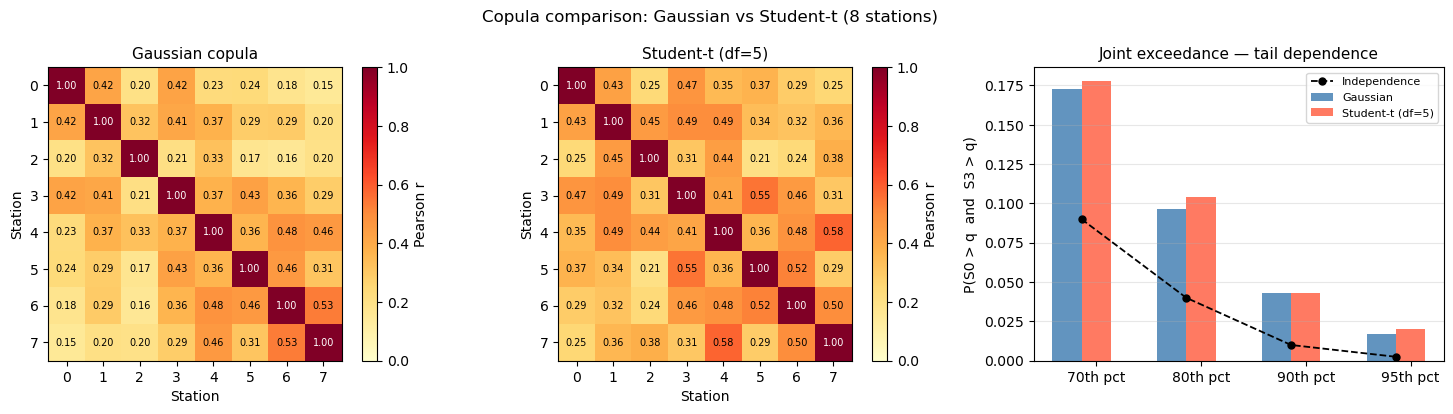

In [9]:
import time

_stcs = {
    "scfid": "weibull", "tcfid": "weibull", "copulaarg": 2.0,
    "scfarg": {"scale": 5.0, "shape": 0.8},
    "tcfarg": {"scale": 3.0, "shape": 0.8},
}

print("Fitting Gaussian copula model ...")
model_gauss = SpatialFieldModel(
    dist="gengamma", dist_params={"scale": 5.0, "shape1": 0.8, "shape2": 0.5},
    p0=0.65, dep_structure="gauss", stcs_id="clayton", stcs_params=_stcs,
)
t0 = time.time(); model_gauss.fit(spacepoints=coords); print(f"  done in {time.time()-t0:.1f}s")

print("Fitting Student-t copula model (df=5) ...")
model_student = SpatialFieldModel(
    dist="gengamma", dist_params={"scale": 5.0, "shape1": 0.8, "shape2": 0.5},
    p0=0.65, dep_structure="student", dep_arg=5.0,
    stcs_id="clayton", stcs_params=_stcs,
)
t0 = time.time(); model_student.fit(spacepoints=coords); print(f"  done in {time.time()-t0:.1f}s")

n_sim = 5000
fg = np.asarray(model_gauss.simulate(n_steps=n_sim))
fs = np.asarray(model_student.simulate(n_steps=n_sim))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Panel 1 & 2: inter-station correlation matrices ─────────────────────────
for ax, arr, title in zip(axes[:2], [fg, fs], ["Gaussian copula", "Student-t (df=5)"]):
    corr = np.corrcoef(arr.T)
    im = ax.imshow(corr, vmin=0, vmax=1, cmap="YlOrRd")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Station"); ax.set_ylabel("Station")
    ax.set_xticks(range(len(coords))); ax.set_yticks(range(len(coords)))
    for i in range(len(coords)):
        for j in range(len(coords)):
            ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
                    fontsize=7, color="black" if corr[i,j] < 0.7 else "white")
    plt.colorbar(im, ax=ax, label="Pearson r")

# ── Panel 3: joint exceedance at several quantile levels ────────────────────
# S0 and S3 are at moderate distance (coords[0]=[0,0], coords[3]=[2.5,4])
s0, s1 = 0, 3
quantiles = [0.70, 0.80, 0.90, 0.95]
je_g, je_s = [], []
for q in quantiles:
    je_g.append(((fg[:, s0] > np.percentile(fg[:, s0], q*100)) &
                 (fg[:, s1] > np.percentile(fg[:, s1], q*100))).mean())
    je_s.append(((fs[:, s0] > np.percentile(fs[:, s0], q*100)) &
                 (fs[:, s1] > np.percentile(fs[:, s1], q*100))).mean())

x = np.arange(len(quantiles)); w = 0.28
axes[2].bar(x - w,   je_g, w, label="Gaussian",       color="steelblue", alpha=0.85)
axes[2].bar(x,       je_s, w, label="Student-t (df=5)", color="tomato",   alpha=0.85)
axes[2].plot(x - w/2, [(1-q)**2 for q in quantiles], "k--o", ms=5, lw=1.3, label="Independence")
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"{int(q*100)}th pct" for q in quantiles])
axes[2].set_ylabel(f"P(S{s0} > q  and  S{s1} > q)")
axes[2].set_title("Joint exceedance — tail dependence", fontsize=11)
axes[2].legend(fontsize=8); axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Copula comparison: Gaussian vs Student-t (8 stations)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nMean inter-station correlation — Gaussian: {np.corrcoef(fg.T)[np.triu_indices(8,1)].mean():.3f}"
      f"   Student-t: {np.corrcoef(fs.T)[np.triu_indices(8,1)].mean():.3f}")
print(f"Joint exceedance at 90th pct (S{s0} vs S{s1}):"
      f"  Gaussian={je_g[2]:.4f}  Student-t={je_s[2]:.4f}  Independence={(1-0.9)**2:.4f}")

### Reading the copula comparison figure

**Correlation heatmaps (panels 1–2):** Off-diagonal entries show Pearson correlation between each pair of stations. Both copulas produce similar mean correlations — this is expected since the STCS is identical for both models. The copula type mainly affects *joint extreme events*, not the overall correlation structure.

**Joint exceedance (panel 3):** P(S0 > q AND S3 > q) at several quantile thresholds. Key observations:
- **Student-t ≥ Gaussian** at all quantiles → the Student-t generates more simultaneous extremes at distant stations
- Both exceed the **independence benchmark** (black dashed) by a large margin, confirming spatial dependence is being reproduced correctly
- The gap between Gaussian and Student-t grows at higher quantiles (95th pct) — this is **tail dependence** in action

**Practical guidance:** use `dep_structure='student'` with `dep_arg=5` when your application is sensitive to concurrent extremes (flood frequency analysis, infrastructure design for compound events).

---
## 5. Advection

**Advection** translates the precipitation field in space between consecutive time steps, simulating the movement of storm systems. Without advection, each day's field is positioned independently of the previous one.

### Physical meaning of `advection_params`

- `u` — eastward displacement per time step (positive = westerly storm moving east)
- `v` — northward displacement per time step (positive = southerly storm moving north)

Units match the `spacepoints` coordinate units — pixel widths for regular grids, km for station coordinates.

### Available patterns

| `advection_id` | Description |
|----------------|-------------|
| `uniform` | Constant wind vector (u, v) — most common |
| `rotation` | Rotating storm (cyclone/anticyclone) |
| `spiral` | Spiral advection pattern |

**Example used here:** `u=1.0, v=0.0` — uniform eastward advection of 1 pixel/day, typical of Atlantic fronts.

Fitting advection model ...
  done in 3.9s


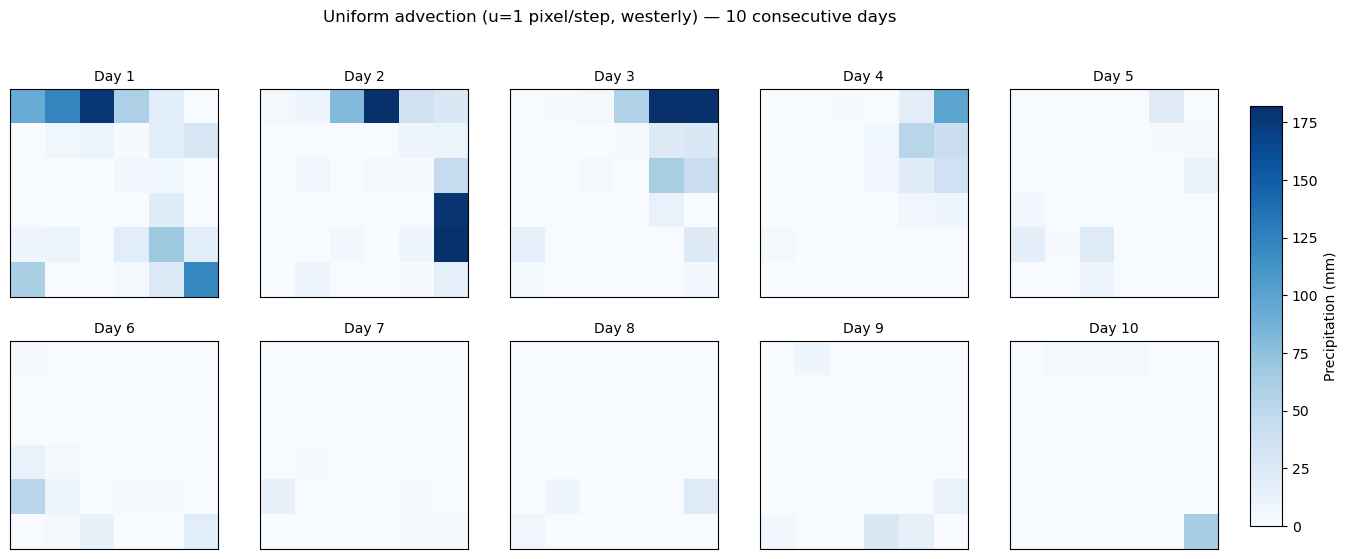

In [10]:
import time

# Westerly advection at 1 pixel/step — fit on 6×6 grid
print("Fitting advection model ...")
model_adv = SpatialFieldModel(
    dist="gengamma",
    dist_params={"scale": 5.0, "shape1": 0.8, "shape2": 0.5},
    p0=0.65,
    stcs_id="clayton",
    stcs_params={
        "scfid": "weibull", "tcfid": "weibull", "copulaarg": 2.0,
        "scfarg": {"scale": 2.0, "shape": 0.8},
        "tcfarg": {"scale": 3.0, "shape": 0.8},
    },
    advection_id="uniform",
    advection_params={"u": 1.0, "v": 0.0},   # u = East-West, v = North-South
)
t0 = time.time(); model_adv.fit(spacepoints=6)
print(f"  done in {time.time()-t0:.1f}s")
field_adv = np.asarray(model_adv.simulate(n_steps=10))
m = 6
vmax = np.percentile(field_adv, 99)   # clip extreme outliers for display

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i in range(10):
    ax = axes[i // 5][i % 5]
    Z = field_adv[i].reshape(m, m)
    im = ax.imshow(Z, cmap="Blues", vmin=0, vmax=vmax, origin="lower")
    ax.set_title(f"Day {i+1}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Precipitation (mm)")
plt.suptitle(
    "Uniform advection (u=1 pixel/step, westerly) — 10 consecutive days",
    fontsize=12, y=1.01,
)
plt.show()

### Reading the advection figure

Each panel shows one day of the simulated 6×6 precipitation field. With `u=1.0, v=0.0` (uniform eastward advection), the wet region shifts approximately one pixel to the right each day — compare Day 1 vs Day 5, the storm pattern has translated ~4 pixels eastward.

When the storm exits the right edge of the domain, it re-enters from the left (periodic boundary conditions). This spatial continuity is critical for realistic storm tracking and for computing spatially aggregated statistics such as areal rainfall over a catchment.

**Effect on temporal correlation:** advection increases the observed lag-1 correlation at a fixed point — the same storm "passing through" means consecutive days at a pixel tend to both be wet. This is in addition to the temporal persistence already encoded in `tcfarg`.

---
## 6. DataFrame output

`simulate_dataframe` wraps the raw ndarray into a `pd.DataFrame` with a `DatetimeIndex` — ready for pandas workflows or export.

### Arguments

| Argument | Default | Description |
|----------|---------|-------------|
| `n_steps` | — | Number of time steps (e.g. 3650 = 10 years of daily data) |
| `start_date` | `'2000-01-01'` | First date of the index |
| `freq` | `'D'` | Pandas frequency string: `'D'` (daily), `'h'` (hourly), `'ME'` (monthly) |
| `fast` | `False` | Use the fast Cholesky variant |

### Typical post-processing

```python
# Annual totals at each pixel
annual = df_field.resample("YE").sum()

# Spatially averaged time series (basin average)
basin_avg = df_field.mean(axis=1)

# Wet-day fraction by month
wet_frac = (df_field > 0).resample("ME").mean()

# Save to CSV
df_field.to_csv("precipitation_simulation.csv")

# Convert to xarray DataArray for spatial analysis
import xarray as xr
da = xr.DataArray(df_field.values, dims=["time", "site"],
                  coords={"time": df_field.index})
```

In [11]:
# Simulate using DataFrame output with DatetimeIndex
df_field = model_precip.simulate_dataframe(
    n_steps=3650,
    start_date="1990-01-01",
    freq="D",
)
print(f"df_field shape: {df_field.shape}")     # (3650, 36)
print(df_field.iloc[:2, :4])

# Annual precipitation at each grid cell
annual = df_field.resample("YE").sum()
print(f"\nAnnual precipitation range: {annual.values.min().round(0):.0f} – {annual.values.max().round(0):.0f} mm")


df_field shape: (3650, 36)
              site_0     site_1  site_2    site_3
1990-01-01  2.894928   0.548752     0.0  1.639672
1990-01-02  5.665241  20.860306     0.0  0.000000

Annual precipitation range: 472 – 7304 mm


---
## 7. Diagnostics

`diagnostics()` runs an internal simulation and compares sample statistics against the **target** values specified in the model. This is a convergence check — it does not use any observed data.

### Statistics compared

| Statistic | Description |
|-----------|-------------|
| `mean` | Daily mean (wet + dry days combined) |
| `sd` | Standard deviation |
| `skew` | Pearson skewness coefficient |
| `p0` | Fraction of exact zeros (dry days) |

### What to look for

- **`p0`** should match the target within ±0.05. If it drifts, re-check the `p0` parameter.
- **`mean` and `sd`** have higher Monte Carlo variance — expect ±20–30% for 500-step simulations.
- **`skew`** is the hardest to reproduce (rare extremes are undersampled); ±40% is acceptable.
- If `mean` is systematically low: increase `scale` in `dist_params`.
- For tighter convergence, use `n_steps ≥ 5000`.

### Note on spatial variability

Each pixel is an independent realisation of the same process — variability across pixels in the diagnostic table is **expected and normal**. The `expected` row should fall within the range of the sample values.

In [12]:
# Run a 500-step simulation and compare statistics against target
diag = model_precip.diagnostics(n_steps=500)

print("Marginal statistics (expected vs sample locations):")
print(diag.round(3).to_string())


Marginal statistics (expected vs sample locations):
                      mean      sd   skew     p0
expected             7.280  23.448  7.680  0.650
sample location 1    4.919  15.537  4.848  0.714
sample location 2    4.546  13.005  4.930  0.664
sample location 3    5.961  17.364  4.764  0.664
sample location 4    6.987  18.998  5.624  0.624
sample location 5    9.062  26.329  4.572  0.622
sample location 6    9.731  26.322  5.198  0.622
sample location 7    3.320  11.281  5.498  0.728
sample location 8    4.449  12.889  4.044  0.662
sample location 9    6.964  20.392  4.647  0.666
sample location 10   8.077  21.684  3.968  0.658
sample location 11   8.429  23.267  4.244  0.644
sample location 12   9.162  21.005  3.481  0.562
sample location 13   5.605  17.263  4.682  0.684
sample location 14   5.685  16.606  4.780  0.700
sample location 15   5.679  14.600  4.054  0.638
sample location 16   8.890  22.772  3.618  0.648
sample location 17   9.052  30.407  7.823  0.642
sample location 1

### Reading the diagnostics table

The first row (`expected`) shows the **target** moments implied by `dist` + `dist_params` + `p0`. Each subsequent row is a single pixel sampled from a 500-step simulation. Key observations:

- **`p0` ≈ 0.65** across all locations — the dry-day fraction is well reproduced ✓
- **`mean` and `sd`** scatter around the target due to Monte Carlo variance (500 steps ≈ 1.4 years is a relatively short record). Re-run with `n_steps=5000` for tighter estimates.
- **`skew`** is consistently lower than the target — this is normal for short simulations since the rare extreme events that drive skewness are under-sampled.

The spread across pixels is expected — each pixel is an independent random realisation from the same model. If the `expected` row falls systematically outside the range of sample values, that signals a convergence problem in the VAR fitting.

---
## 8. Continuous variable — no zeros

For **temperature, wind speed, or base flow** — variables that are never exactly zero — set `p0=0`. No zero-truncation is applied and every time step receives a positive value.

### Recommended settings by variable type

| Variable | `dist` | Example `dist_params` | `p` | Notes |
|----------|--------|-----------------------|-----|-------|
| Temperature | `gengamma` | scale=10, shape1=5, shape2=1 | 2 | With shape1≫1, shape2=1 → near-Gamma / near-normal shape |
| Wind speed | `burrXII` | scale=5, shape1=2, shape2=3 | 1 | Heavy right tail |
| Base flow | `paretoII` | scale=8, shape=0.3 | 1 | Power-law tail |

### VAR order `p=2`

Using `p=2` introduces two lags of autocorrelation, creating longer **memory** (smoother day-to-day variation). This is realistic for temperature (multi-day weather patterns) but slower to fit. For precipitation, `p=1` is generally sufficient.

### Gneiting14 STCS for continuous fields

Unlike the Clayton STCS (separable spatial × temporal ACFs), Gneiting14 is a **non-separable** model: the spatial range shrinks as time lag increases, mimicking the spatial decorrelation of weather systems over time.

**Parameters used here:** `a=0.5, c=0.8, alpha=0.7, beta=0.3, gamma=0.8, tau=1.0`  
— produces spatially smoother fields (gamma=0.8 > 0.5) with moderate temporal persistence.

### Comparison with the target distribution

The code compares the simulated histogram against the `Gamma(k=3, θ=4)` density, which is the special case of `gengamma(scale=4, shape1=3, shape2=1)`. This confirms that the marginal distribution is correctly reproduced by the ACTF transform.

Fitting continuous-field model (gengamma, VAR(2), Gneiting14) ...
  done in 5.4s
Shape: (365, 8)  (365 days × 8 stations)
Mean ± std: 12.00 ± 6.83


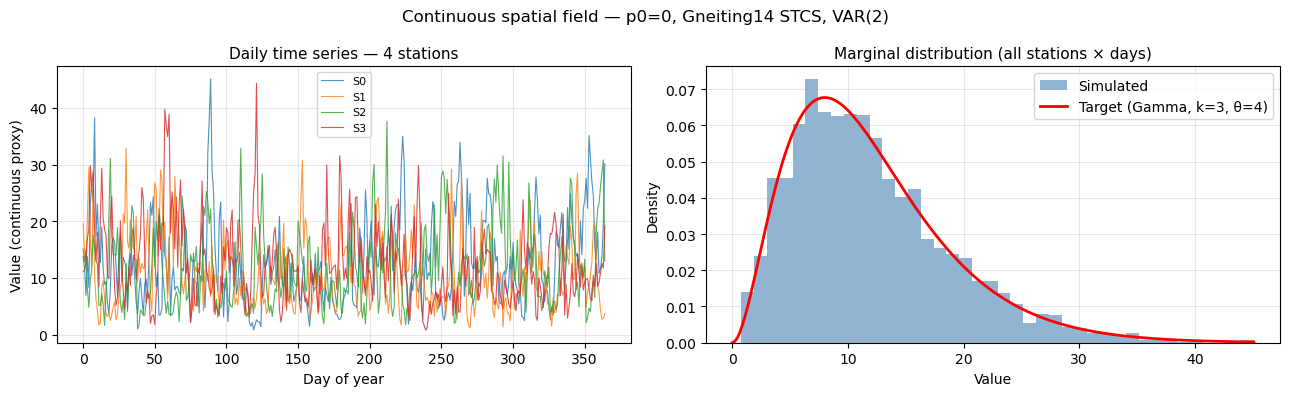

In [13]:
import time
from scipy.stats import gamma as sp_gamma

# Generalised gamma with p0=0 → no zeros; VAR(2) for longer autocorrelation.
# scale=12, shape1=3, shape2=1 → gamma-like with mean ≈ 36 (rescale for demo)
# We use scale=4, shape1=3, shape2=1 → mean ≈ 12 (temperature proxy)
print("Fitting continuous-field model (gengamma, VAR(2), Gneiting14) ...")
model_cont = SpatialFieldModel(
    dist="gengamma",
    dist_params={"scale": 4.0, "shape1": 3.0, "shape2": 1.0},
    p0=0.0,
    p=2,
    stcs_id="gneiting14",
    stcs_params={"a": 0.5, "c": 0.8, "alpha": 0.7,
                 "beta": 0.3, "gamma": 0.8, "tau": 1.0},
)
t0 = time.time(); model_cont.fit(spacepoints=coords)
print(f"  done in {time.time()-t0:.1f}s")
field_cont = np.asarray(model_cont.simulate(n_steps=365))

print(f"Shape: {field_cont.shape}  (365 days × 8 stations)")
print(f"Mean ± std: {field_cont.mean():.2f} ± {field_cont.std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time series — 4 stations
for i in range(4):
    axes[0].plot(field_cont[:, i], lw=0.8, alpha=0.8, label=f"S{i}")
axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Value (continuous proxy)")
axes[0].set_title("Daily time series — 4 stations", fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Marginal histogram (gengamma shape1=3, shape2=1 → standard gamma with k=3)
axes[1].hist(field_cont.ravel(), bins=40, density=True,
             color="steelblue", alpha=0.6, label="Simulated")
x_range = np.linspace(0, field_cont.max(), 200)
axes[1].plot(x_range, sp_gamma.pdf(x_range, a=3.0, scale=4.0),
             "r-", lw=2, label="Target (Gamma, k=3, θ=4)")
axes[1].set_xlabel("Value"); axes[1].set_ylabel("Density")
axes[1].set_title("Marginal distribution (all stations × days)", fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Continuous spatial field — p0=0, Gneiting14 STCS, VAR(2)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Functional API

The same simulation workflow is available as **standalone functions** — useful for scripting, batch jobs, or pipeline integration without managing object state.

### OOP ↔ functional equivalence

| OOP method | Functional equivalent |
|------------|-----------------------|
| `SpatialFieldModel(...).fit(spacepoints)` | `fit_spatial_model(spacepoints, ...)` → returns `model` dict |
| `.simulate(n_steps)` | `generate_random_field(n_steps, model)` |
| `.simulate(n_steps, fast=True)` | `generate_random_field_fast(n_steps, model)` ¹ |
| `.diagnostics(n_steps)` | `check_random_field(field, model)` |

¹ The fast variant requires explicit (n×2) coordinate arrays — integer grid sizes are not accepted.

### When to use each API

- **OOP API** (`SpatialFieldModel`) — interactive work, notebooks, when re-simulating with the same fitted model without recomputing the VAR.
- **Functional API** — scripting, pipeline integration, when direct access to the raw `model` dict is needed.

### The `model` dict

The dict returned by `fit_spatial_model` contains the full VAR(p) coefficient matrices and all fitted parameters. It can be serialised to avoid re-fitting on repeated runs:

```python
import pickle

# Save fitted model
pickle.dump(var_model, open("var_model_6x6.pkl", "wb"))

# Load and simulate without re-fitting
var_model = pickle.load(open("var_model_6x6.pkl", "rb"))
field = generate_random_field(365, var_model)
```

In [14]:
import time

print("Functional API: fit_spatial_model + generate_random_field")
t0 = time.time()
var_model = fit_spatial_model(
    spacepoints=6,
    p=1,
    dist="gengamma",
    dist_params={"scale": 5.0, "shape1": 0.8, "shape2": 0.5},
    p0=0.65,
    stcs_id="clayton",
    stcs_params={
        "scfid": "weibull", "tcfid": "weibull",
        "copulaarg": 2.0,
        "scfarg": {"scale": 2.0, "shape": 0.8},
        "tcfarg": {"scale": 3.0, "shape": 0.8},
    },
)
print(f"  Model fitted in {time.time()-t0:.1f}s")

field_fn = generate_random_field(365, var_model)
field_fn_arr = np.asarray(field_fn)
print(f"  Simulated field shape: {field_fn_arr.shape}")
print(f"  Mean: {field_fn_arr.mean():.2f} mm   Wet fraction: {(field_fn_arr > 0).mean():.3f}")

# Note: generate_random_field_fast requires explicit (n_sites × 2) coordinates.

# Diagnostics
diag = check_random_field(field_fn, var_model)
print("\nDiagnostics (expected vs first 6 locations):")
print(diag.head(7).round(3).to_string())

Functional API: fit_spatial_model + generate_random_field
  Model fitted in 3.9s
  Simulated field shape: (365, 36)
  Mean: 7.28 mm   Wet fraction: 0.351

Diagnostics (expected vs first 6 locations):
                     mean      sd   skew     p0
expected            7.280  23.448  7.680  0.650
sample location 1   7.683  22.720  5.232  0.619
sample location 2   7.980  17.871  3.399  0.586
sample location 3  11.571  27.244  3.662  0.589
sample location 4  10.132  22.174  3.280  0.600
sample location 5   8.055  22.502  4.689  0.655
sample location 6   8.452  23.118  4.444  0.658
